In [1]:
import pandas as pd
retailler = pd.read_excel("online_retail_II.xlsx")
print(retailler.head())

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [2]:
print("Shape : \n{}".format(retailler.shape))

Shape : 
(525461, 8)


In [3]:
print("Columns : \n{}".format(retailler.columns))

Columns : 
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')


In [4]:
print("Type :\n",retailler.dtypes)

Type :
 Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [5]:
print("Duplicate : \n{}".format(retailler.duplicated()))

Duplicate : 
0         False
1         False
2         False
3         False
4         False
          ...  
525456    False
525457    False
525458    False
525459    False
525460    False
Length: 525461, dtype: bool


In [6]:
print("Duplicate Sum : \n{}".format(retailler.duplicated().sum()))

Duplicate Sum : 
6865


In [7]:
print("Empty : \n{}".format(retailler.isnull()))

Empty : 
        Invoice  StockCode  Description  Quantity  InvoiceDate  Price  \
0         False      False        False     False        False  False   
1         False      False        False     False        False  False   
2         False      False        False     False        False  False   
3         False      False        False     False        False  False   
4         False      False        False     False        False  False   
...         ...        ...          ...       ...          ...    ...   
525456    False      False        False     False        False  False   
525457    False      False        False     False        False  False   
525458    False      False        False     False        False  False   
525459    False      False        False     False        False  False   
525460    False      False        False     False        False  False   

        Customer ID  Country  
0             False    False  
1             False    False  
2             False  

In [8]:
print("Empty Sum : \n{}".format(retailler.isnull().sum()))

Empty Sum : 
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [9]:
print("Dropping : \n{}".format(retailler.dropna()))

Dropping : 
       Invoice StockCode                          Description  Quantity  \
0       489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1       489434    79323P                   PINK CHERRY LIGHTS        12   
2       489434    79323W                  WHITE CHERRY LIGHTS        12   
3       489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4       489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   
...        ...       ...                                  ...       ...   
525456  538171     22271                 FELTCRAFT DOLL ROSIE         2   
525457  538171     22750         FELTCRAFT PRINCESS LOLA DOLL         1   
525458  538171     22751       FELTCRAFT PRINCESS OLIVIA DOLL         1   
525459  538171     20970   PINK FLORAL FELTCRAFT SHOULDER BAG         2   
525460  538171     21931               JUMBO STORAGE BAG SUKI         2   

               InvoiceDate  Price  Customer ID         Country  
0      2009-12-01 07:4

In [10]:
print(retailler['Quantity'])

0         12
1         12
2         12
3         48
4         24
          ..
525456     2
525457     1
525458     1
525459     2
525460     2
Name: Quantity, Length: 525461, dtype: int64


In [11]:
retailler['revenue'] = retailler['Quantity'] * retailler['Price']
print("Revenue : \n{}".format(retailler['revenue']))

Revenue : 
0          83.40
1          81.00
2          81.00
3         100.80
4          30.00
           ...  
525456      5.90
525457      3.75
525458      3.75
525459      7.50
525460      3.90
Name: revenue, Length: 525461, dtype: float64


In [12]:
grouped = retailler.groupby('StockCode')
total = grouped['Quantity'].sum()
sorted_data = total.sort_values(ascending = False)
print(sorted_data.head(10))
total_rev = grouped['revenue'].sum()
sorted_rev = total_rev.sort_values(ascending = False)
print(sorted_rev.head(10))

StockCode
21212     59411
85123A    57236
84077     54698
85099B    48376
17003     47647
84879     44484
84991     36326
21977     31822
21232     26563
21213     25516
Name: Quantity, dtype: int64
StockCode
22423     163051.46
85123A    155825.52
DOT       116401.99
85099B     88922.48
84879      72454.12
22086      57870.20
47566      49645.52
84347      47672.49
POST       46092.36
21843      42333.85
Name: revenue, dtype: float64


In [13]:
per_country_sales = retailler.groupby('Country')['revenue'].sum()
per_country_sales = per_country_sales.sort_values(ascending = False)
print(per_country_sales)

Country
United Kingdom          8194777.533
EIRE                     352242.730
Netherlands              263863.410
Germany                  196290.351
France                   130769.900
Sweden                    51213.510
Denmark                   46972.950
Switzerland               43343.410
Spain                     37084.900
Australia                 30051.800
Portugal                  23769.780
Belgium                   22663.530
Channel Islands           21367.320
Greece                    14284.970
Italy                     13788.840
Austria                   13023.280
Cyprus                    11216.450
Japan                      8435.960
United Arab Emirates       8046.370
Finland                    7187.710
Unspecified                4937.530
Lithuania                  4892.680
USA                        4555.620
Norway                     4079.570
Singapore                  4037.770
Hong Kong                  3922.260
Poland                     3314.950
Israel              

In [14]:
retailler['InvoiceDate'] = pd.to_datetime(retailler['InvoiceDate'])
#print(retailler['InvoiceDate'])
retailler['Month'] = retailler['InvoiceDate'].dt.to_period("M")
#print(retailler['InvoiceDate'])
monthly_revenue = retailler.groupby("Month")["revenue"].sum()
print(monthly_revenue)

Month
2009-12     799847.110
2010-01     624032.892
2010-02     533091.426
2010-03     765848.761
2010-04     590580.432
2010-05     615322.830
2010-06     679786.610
2010-07     575236.360
2010-08     656776.340
2010-09     853650.431
2010-10    1045168.350
2010-11    1422654.642
2010-12     377488.450
Freq: M, Name: revenue, dtype: float64


C:\Users\hisha\AppData\Local\Temp\ipykernel_21508\544698280.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


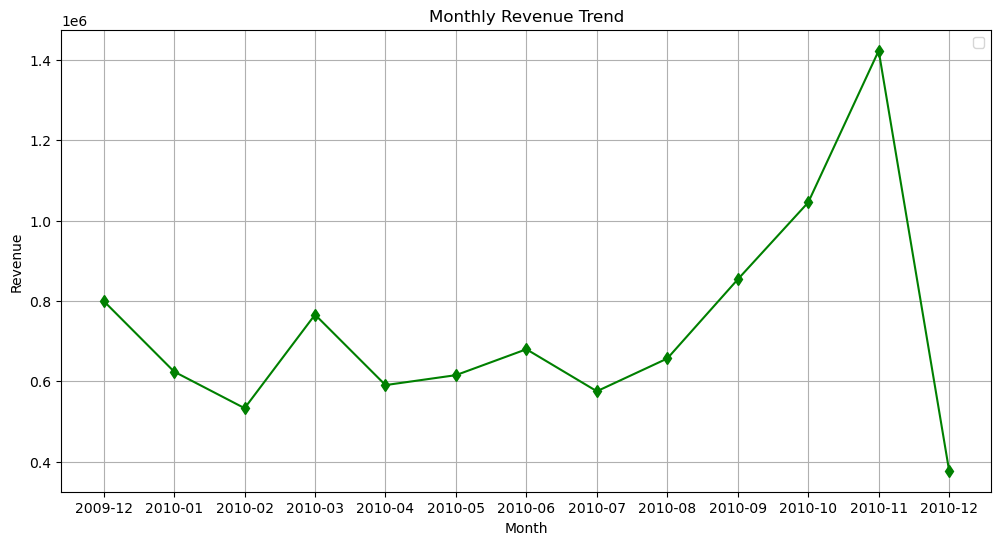

In [45]:
#now plotting
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values , marker ='d',color= "green")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

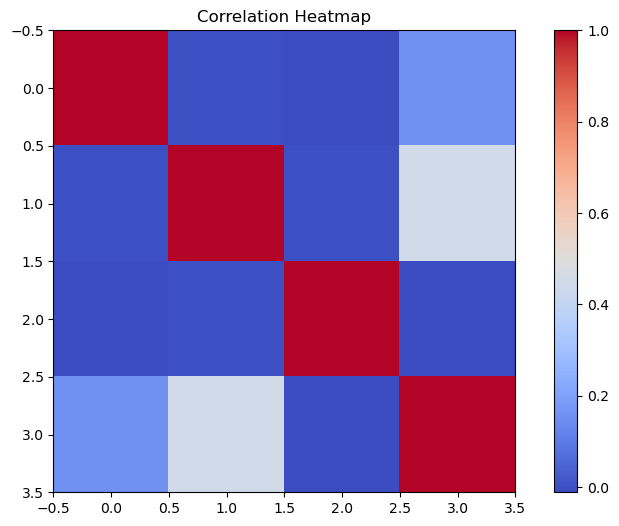

In [21]:
#heatmap
import matplotlib.pyplot as plt
number_data_in_ds = retailler.select_dtypes(include="number")
correlation = number_data_in_ds.corr()
plt.figure(figsize =(10,6))
plt.imshow(correlation , cmap = "coolwarm")
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

C:\Users\hisha\AppData\Local\Temp\ipykernel_21508\1395049531.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


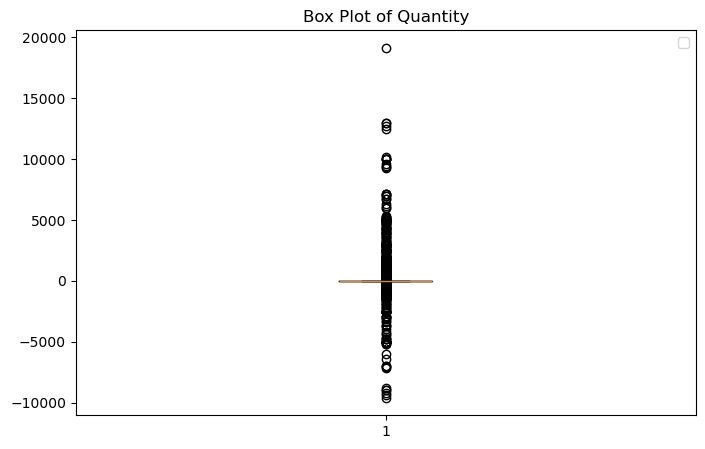

In [44]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.boxplot(retailler["Quantity"])
plt.title("Box Plot of Quantity")
plt.show()

In [43]:
#Busniess insights
#1
print(per_country_sales.head(1),end="\n\n")
#2
print(sorted_rev.head(1),end="\n\n")
#3
print(retailler['Customer ID'].isnull().sum(),end="\n\n")
#4
print(retailler['Quantity'].max(),end="\n\n")
#5
print(monthly_revenue.values.max())

Country
United Kingdom    8194777.533
Name: revenue, dtype: float64

StockCode
22423    163051.46
Name: revenue, dtype: float64

107927

19152

1422654.642
